PROJECT TITLE: 
DESCRIPTION:
OBJECTIVE:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset bersih
data_path = "../data/processed/cleaned_sales.csv"
df = pd.read_csv(data_path)

# Lihat 5 data pertama
df.head()

,Region,Salesperson,Revenue,Profit,Units_Sold,Customer_Satisfaction,Marketing_Spend,Discount_Percentage,Product_Category,Sales_Channel,Order_Processing_Time
0,East,Alice,137118,10067,219,4.06,14666,13.40,Furniture,Retail,1
1,West,Alice,78577,38481,750,2.64,8254,3.70,Automobile,Wholesale,3
2,North,Alice,19078,28037,406,3.62,14746,6.18,Furniture,Retail,3
3,East,Eve,166075,10557,109,2.04,4578,0.03,Furniture,Online,5
4,East,David,72768,10435,40,1.64,13353,1.18,Electronics,Wholesale,3


STATISTIK DASAR

In [2]:
# Statistik deskriptif
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Region                 1000 non-null   str    
 1   Salesperson            1000 non-null   str    
 2   Revenue                1000 non-null   int64  
 3   Profit                 1000 non-null   int64  
 4   Units_Sold             1000 non-null   int64  
 5   Customer_Satisfaction  1000 non-null   float64
 6   Marketing_Spend        1000 non-null   int64  
 7   Discount_Percentage    1000 non-null   float64
 8   Product_Category       1000 non-null   str    
 9   Sales_Channel          1000 non-null   str    
 10  Order_Processing_Time  1000 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 86.1 KB


,Revenue,Profit,Units_Sold,Customer_Satisfaction,Marketing_Spend,Discount_Percentage,Order_Processing_Time
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,107315.608000,23973.118000,498.594000,2.963420,10181.017000,14.98931,4.963000
std,55015.118415,14067.263525,282.337202,1.147817,5648.219494,8.66553,2.625362
min,10163.000000,1097.000000,10.000000,1.000000,501.000000,0.03000,1.000000
25%,58297.750000,11633.750000,256.000000,1.950000,5414.250000,7.55000,3.000000
50%,108841.000000,23020.500000,502.500000,2.950000,9912.500000,14.71000,5.000000
75%,155577.750000,35622.500000,738.500000,3.960000,15130.250000,22.22750,7.000000
max,199784.000000,49980.000000,999.000000,5.000000,19980.000000,29.98000,9.000000


Exploratory Data Analysis (EDA)

In [3]:
df[['Revenue','Profit','Units_Sold']].sum()

Revenue       107315608
Profit         23973118
Units_Sold       498594
dtype: int64

<Axes: xlabel='Revenue', ylabel='Count'>

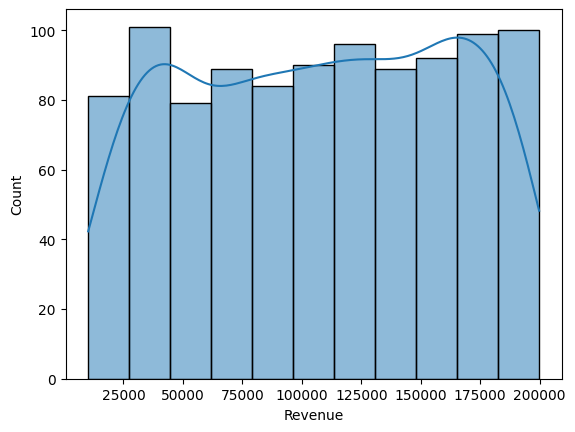

In [4]:
sns.histplot(df['Revenue'], kde=True)

<Axes: >

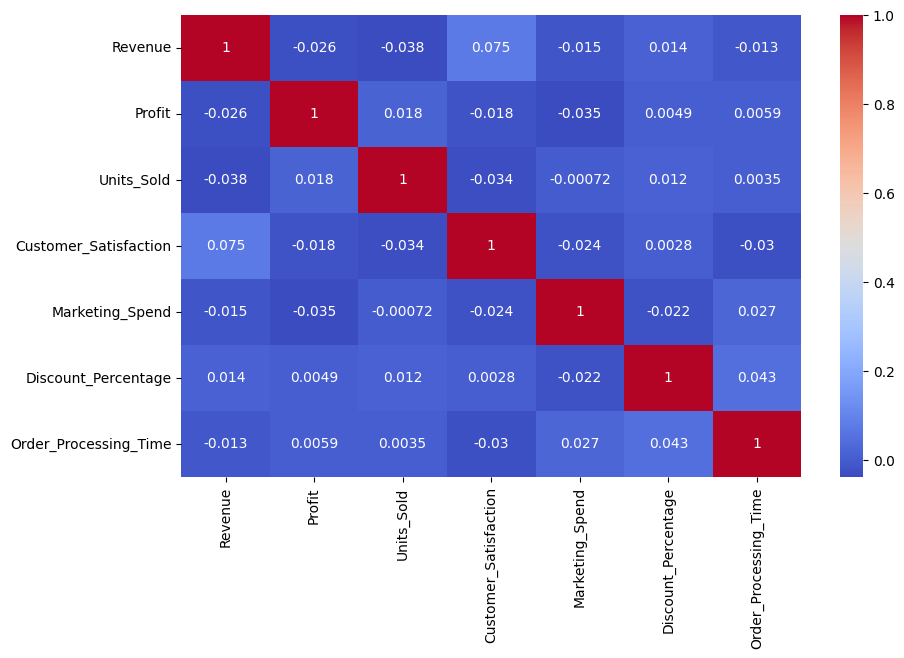

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

<Axes: xlabel='Revenue', ylabel='Profit'>

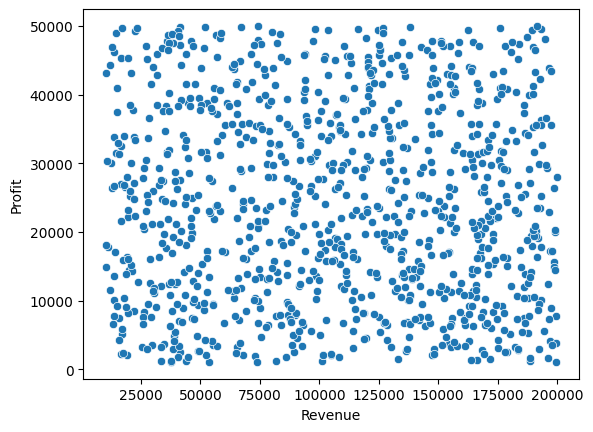

In [6]:
sns.scatterplot(x='Revenue', y='Profit', data=df)

<Axes: xlabel='Discount_Percentage', ylabel='Profit'>

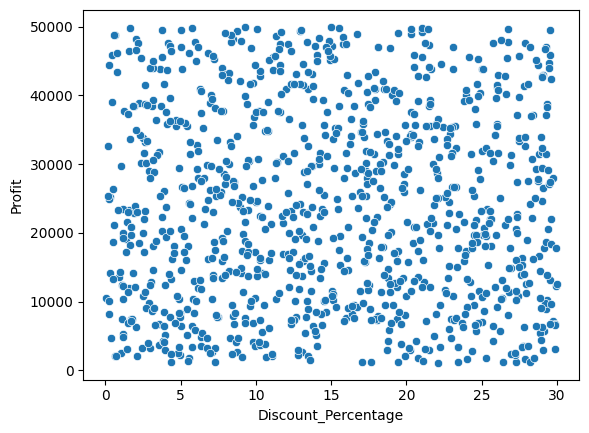

In [7]:
sns.scatterplot(x='Discount_Percentage', y='Profit', data=df)

<Axes: xlabel='Marketing_Spend', ylabel='Revenue'>

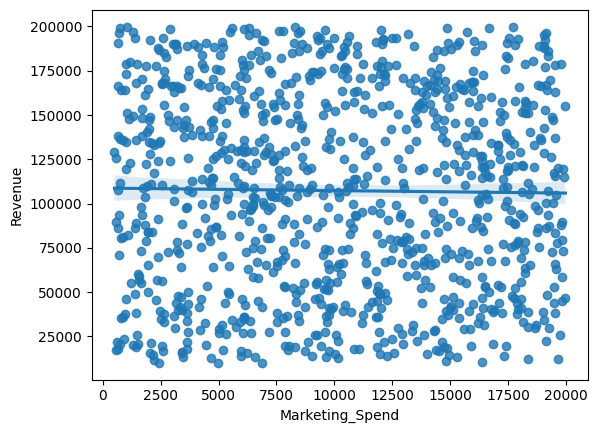

In [8]:
sns.regplot(x='Marketing_Spend', y='Revenue', data=df)

<Axes: xlabel='Region'>

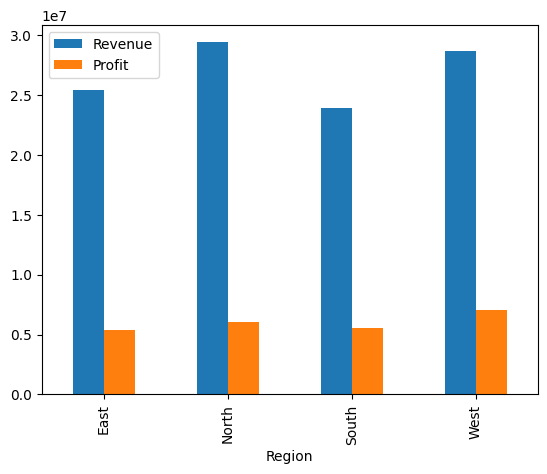

In [9]:
df.groupby('Region')[['Revenue','Profit']].sum().plot(kind='bar')

<Axes: xlabel='Product_Category'>

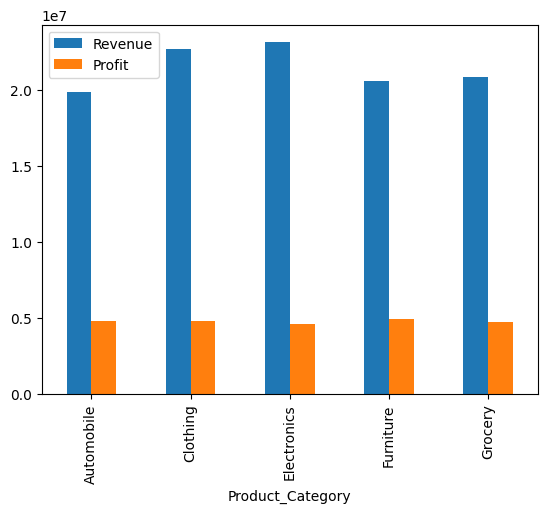

In [15]:
df.groupby('Product_Category')[['Revenue','Profit']].sum().plot(kind='bar')

<Axes: ylabel='Salesperson'>

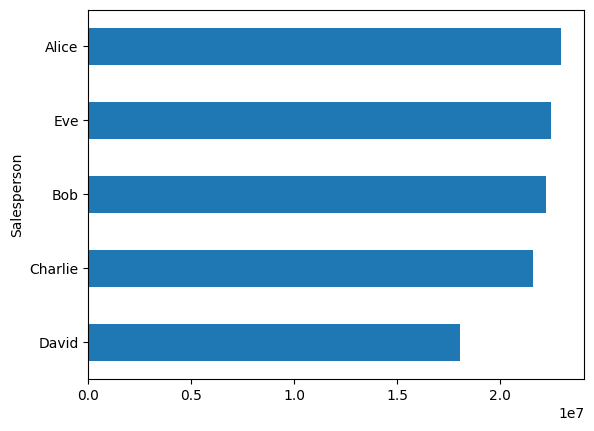

In [10]:
df.groupby('Salesperson')['Revenue'].sum().sort_values().plot(kind='barh')


<Axes: xlabel='Product_Category', ylabel='Customer_Satisfaction'>

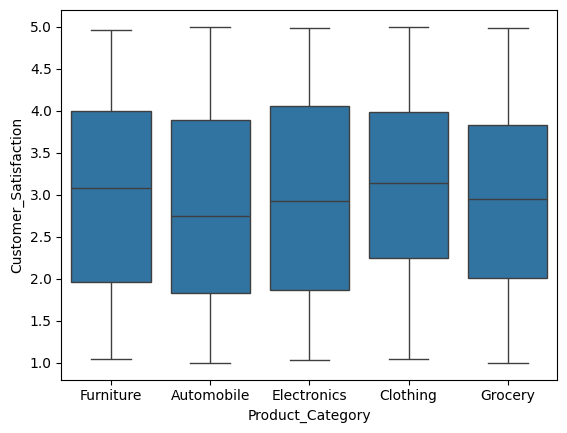

In [11]:
sns.boxplot(x='Product_Category', y='Customer_Satisfaction', data=df)


<Axes: xlabel='Order_Processing_Time', ylabel='Customer_Satisfaction'>

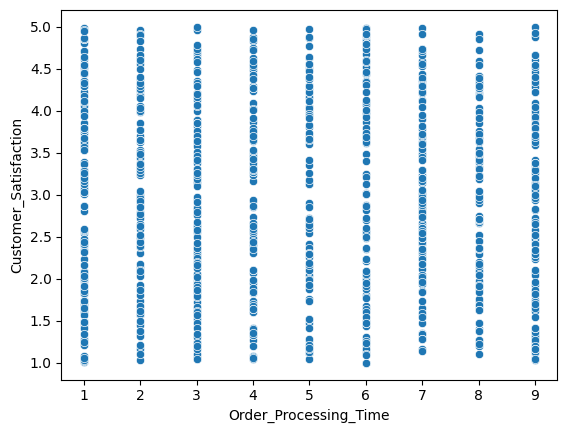

In [12]:
sns.scatterplot(x='Order_Processing_Time', y='Customer_Satisfaction', data=df)

In [13]:
df.corr(numeric_only=True)

,Revenue,Profit,Units_Sold,Customer_Satisfaction,Marketing_Spend,Discount_Percentage,Order_Processing_Time
Revenue,1.000000,-0.025888,-0.037776,0.074655,-0.014557,0.014066,-0.013188
Profit,-0.025888,1.000000,0.017895,-0.017598,-0.034590,0.004936,0.005881
Units_Sold,-0.037776,0.017895,1.000000,-0.033571,-0.000722,0.011567,0.003541
Customer_Satisfaction,0.074655,-0.017598,-0.033571,1.000000,-0.023639,0.002799,-0.029592
Marketing_Spend,-0.014557,-0.034590,-0.000722,-0.023639,1.000000,-0.022098,0.026740
Discount_Percentage,0.014066,0.004936,0.011567,0.002799,-0.022098,1.000000,0.043340
Order_Processing_Time,-0.013188,0.005881,0.003541,-0.029592,0.026740,0.043340,1.000000


Conclusion & Insights

Based on the analysis, the dataset shows no significant correlation between key business variables such as Revenue, Profit, Marketing Spend, and Discount Percentage.

For example:

Revenue and Profit have almost zero correlation, which is unusual in real-world business scenarios.
Marketing Spend does not show any meaningful impact on Revenue.
Discount Percentage does not significantly affect Profit.

This suggests that the dataset lacks underlying relationships typically expected in business operations.

From a business perspective, these findings are unexpected. In most real-world scenarios, increasing marketing spend should lead to higher revenue, and offering higher discounts typically reduces profit margins.

However, the absence of these relationships in the dataset indicates that:

The data may have been artificially generated
Important variables (such as cost structure or customer segmentation) may be missing
Or the business process itself is highly inefficient and unstructured

This highlights the importance of validating data quality before drawing conclusions, as misleading data can result in incorrect business decisions.

Recommendations
Validate the data source to ensure it reflects real business operations
Include additional variables such as cost, customer segments, or product pricing
Perform segmented analysis (by region or category) to uncover hidden patterns
Improve data collection methods to capture meaningful relationships